# 1 Cross-Source Distance Computation
Compare coordinates from multiple scraped sources (Webscraped, Yelp, Yellow Pages),
compute haversine distances, apply a 200-metre threshold, and calculate midpoints.

Webscraped is treated as the most trusted source. When cross-source distance
exceeds 200 m the pipeline defaults to the Webscraped coordinate and flags
the row for manual review.

Input:  data/1_derived/5_geocode_truck_stops/1_joined_all_sources.csv
Output: data/1_derived/5_geocode_truck_stops/2_cross_source_distances.csv

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from math import radians, cos, sin, asin, sqrt


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'data').exists() and (candidate / 'source').exists() and (candidate / 'temp').exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
IN_FILE  = PROJECT_ROOT / 'data' / '1_derived' / '5_geocode_truck_stops' / '1_joined_all_sources.csv'
OUT_DIR  = PROJECT_ROOT / 'data' / '1_derived' / '5_geocode_truck_stops'
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_FILE = OUT_DIR / '2_cross_source_distances.csv'

df = pd.read_csv(IN_FILE, low_memory=False)
print(f'Loaded {len(df):,} rows')

Loaded 38,135 rows


In [2]:
# Define coordinate sources — Webscraped combines Phone + PlaceMatched LD columns
columns_info = [
    ([('Webscraped_Phone_LD_Latitude', 'Webscraped_Phone_LD_Longitude'),
      ('Webscraped_PlacedMatched_LD_Latitude', 'Webscraped_PlacedMatched_LD_Longitude')], 'Webscraped'),
    ([('Yelp_Latitude', 'Yelp_Longitude')], 'Yelp (Phone)'),
    ([('YellowPages_JSONLD_LAT_1', 'YellowPages_JSONLD_LNG_1')], 'YellowPages (Phone)')
]


def parse_coords(lat_str, lon_str):
    exclude = {'nan', '', 'None', 'removed'}
    lats = [float(x) for x in str(lat_str).split(';') if x.strip() not in exclude]
    lons = [float(x) for x in str(lon_str).split(';') if x.strip() not in exclude]
    return list(zip(lats, lons))


def remove_duplicate_coords(coords):
    unique = []
    for c in coords:
        if c not in unique:
            unique.append(c)
    return unique


def get_single_coordinate_from_duplicates(coords):
    if len(coords) == 1:
        return coords[0]
    unique = remove_duplicate_coords(coords)
    if len(unique) == 1:
        return unique[0]
    return None


def haversine(lat1, lon1, lat2, lon2):
    R = 3958.8  # Earth radius in miles
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat / 2) ** 2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2) ** 2
    return R * 2 * asin(sqrt(a))


def calculate_midpoint(lat1, lon1, lat2, lon2):
    return (lat1 + lat2) / 2, (lon1 + lon2) / 2


THRESHOLD_MILES = 200 / 1609.34  # 200 metres ≈ 0.1243 miles

In [3]:
# Main distance computation loop
max_distances = []
max_distance_sources = []
min_distances = []
min_distance_sources = []
min_distances_unconstrained = []
min_distance_sources_unconstrained = []
mid_lats = []
mid_longs = []
flagged_list = []
flag_reason_list = []

for idx, row in df.iterrows():
    # Collect coordinates from each source
    source_coords = {}
    for column_pairs, label in columns_info:
        all_coords = []
        for lat_col, lon_col in column_pairs:
            if lat_col in row and lon_col in row:
                coords = parse_coords(row[lat_col], row[lon_col])
                if coords:
                    all_coords.extend(coords)
        if all_coords:
            source_coords[label] = remove_duplicate_coords(all_coords)

    # --- Case: No sources have coordinates ---
    if len(source_coords) == 0:
        max_distances.append(0)
        max_distance_sources.append('')
        min_distances.append(0)
        min_distance_sources.append('')
        min_distances_unconstrained.append(0)
        min_distance_sources_unconstrained.append('')
        mid_lats.append(None)
        mid_longs.append(None)
        flagged_list.append(True)
        flag_reason_list.append('No match: no source returned coordinates')
        continue

    # --- Case: Only one source ---
    if len(source_coords) == 1:
        source_name = list(source_coords.keys())[0]
        coords = source_coords[source_name]
        single_coord = get_single_coordinate_from_duplicates(coords)
        if single_coord:
            lat, lon = single_coord
            mid_lats.append(lat)
            mid_longs.append(lon)
            max_distance_sources.append(f'Single source: {source_name}')
            min_distance_sources.append(f'Single source: {source_name}')
            min_distance_sources_unconstrained.append(f'Single source: {source_name}')
        else:
            all_lats = [c[0] for c in coords]
            all_lons = [c[1] for c in coords]
            mid_lats.append(sum(all_lats) / len(all_lats))
            mid_longs.append(sum(all_lons) / len(all_lons))
            max_distance_sources.append(f'Single source (multiple coords): {source_name}')
            min_distance_sources.append(f'Single source (multiple coords): {source_name}')
            min_distance_sources_unconstrained.append(f'Single source (multiple coords): {source_name}')
        max_distances.append(0)
        min_distances.append(0)
        min_distances_unconstrained.append(0)
        flagged_list.append(True)
        flag_reason_list.append(f'Single match: only one source ({source_name}) returned coordinates')
        continue

    # --- Case: Multiple sources — compute distances ---
    source_names = list(source_coords.keys())
    max_dist = 0
    max_source_pair = ''
    min_dist_unc = float('inf')
    min_source_pair_unc = ''
    min_coord_pair_unc = None

    # Unconstrained: all pairs
    for i in range(len(source_names)):
        for j in range(i + 1, len(source_names)):
            for lat1, lon1 in source_coords[source_names[i]]:
                for lat2, lon2 in source_coords[source_names[j]]:
                    dist = haversine(lat1, lon1, lat2, lon2)
                    if dist > max_dist:
                        max_dist = dist
                        max_source_pair = f'{source_names[i]} vs {source_names[j]}'
                    if dist < min_dist_unc:
                        min_dist_unc = dist
                        min_source_pair_unc = f'{source_names[i]} vs {source_names[j]}'
                        min_coord_pair_unc = ((lat1, lon1), (lat2, lon2))

    # Constrained: prioritise Webscraped
    min_dist_con = float('inf')
    min_source_pair_con = ''
    min_coord_pair_con = None
    if 'Webscraped' in source_coords:
        for sn in source_names:
            if sn != 'Webscraped':
                for lat1, lon1 in source_coords['Webscraped']:
                    for lat2, lon2 in source_coords[sn]:
                        dist = haversine(lat1, lon1, lat2, lon2)
                        if dist < min_dist_con:
                            min_dist_con = dist
                            min_source_pair_con = f'Webscraped vs {sn}'
                            min_coord_pair_con = ((lat1, lon1), (lat2, lon2))
    if min_dist_con == float('inf'):
        for i in range(len(source_names)):
            for j in range(i + 1, len(source_names)):
                if source_names[i] != 'Webscraped' and source_names[j] != 'Webscraped':
                    for lat1, lon1 in source_coords[source_names[i]]:
                        for lat2, lon2 in source_coords[source_names[j]]:
                            dist = haversine(lat1, lon1, lat2, lon2)
                            if dist < min_dist_con:
                                min_dist_con = dist
                                min_source_pair_con = f'{source_names[i]} vs {source_names[j]}'
                                min_coord_pair_con = ((lat1, lon1), (lat2, lon2))

    max_distances.append(max_dist)
    max_distance_sources.append(max_source_pair)

    # Unconstrained
    if min_dist_unc == float('inf'):
        min_distances_unconstrained.append(0)
        min_distance_sources_unconstrained.append('')
    else:
        min_distances_unconstrained.append(min_dist_unc)
        min_distance_sources_unconstrained.append(min_source_pair_unc)

    # Constrained — apply 200 m threshold
    if min_dist_con == float('inf'):
        min_distances.append(0)
        min_distance_sources.append('')
        mid_lats.append(None)
        mid_longs.append(None)
        flagged_list.append(True)
        flag_reason_list.append('No cross-source match found')
    elif min_dist_con <= THRESHOLD_MILES:
        (lat1, lon1), (lat2, lon2) = min_coord_pair_con
        mid_lat, mid_lon = calculate_midpoint(lat1, lon1, lat2, lon2)
        min_distances.append(min_dist_con)
        min_distance_sources.append(min_source_pair_con)
        mid_lats.append(mid_lat)
        mid_longs.append(mid_lon)
        flagged_list.append(False)
        flag_reason_list.append('')
    else:
        if 'Webscraped' in source_coords:
            ws = source_coords['Webscraped']
            mid_lats.append(sum(c[0] for c in ws) / len(ws))
            mid_longs.append(sum(c[1] for c in ws) / len(ws))
        else:
            mid_lats.append(None)
            mid_longs.append(None)
        min_distances.append(min_dist_con)
        min_distance_sources.append(min_source_pair_con)
        flagged_list.append(True)
        flag_reason_list.append(
            f'min_distance {min_dist_con * 1609.34:.1f} m '
            f'({min_source_pair_con}) exceeds 200 m threshold; defaulted to Webscraped'
        )

df['max_distance_miles'] = max_distances
df['max_distance_sources'] = max_distance_sources
df['min_distance_miles'] = min_distances
df['min_distance_sources'] = min_distance_sources
df['min_distance_miles_unconstrained'] = min_distances_unconstrained
df['min_distance_sources_unconstrained'] = min_distance_sources_unconstrained
df['Mid_Lat'] = mid_lats
df['Mid_Long'] = mid_longs
df['Flagged'] = flagged_list
df['Flag_Reason'] = flag_reason_list

print(f'Distance computation complete.')
print(f'  Flagged rows: {sum(flagged_list):,}')
print(f'  Unflagged rows: {len(df) - sum(flagged_list):,}')

Distance computation complete.
  Flagged rows: 19,082
  Unflagged rows: 19,053


Total records: 38,135
Records with distance comparisons: 20,948
Records with no distance comparisons: 17,187

Basic statistics for min_distance_miles (excluding zeros):
count    20948.000000
mean         3.886273
std        111.937376
min          0.000169
25%          0.026121
50%          0.041266
75%          0.064376
max       6041.251543
Name: min_distance_miles, dtype: float64


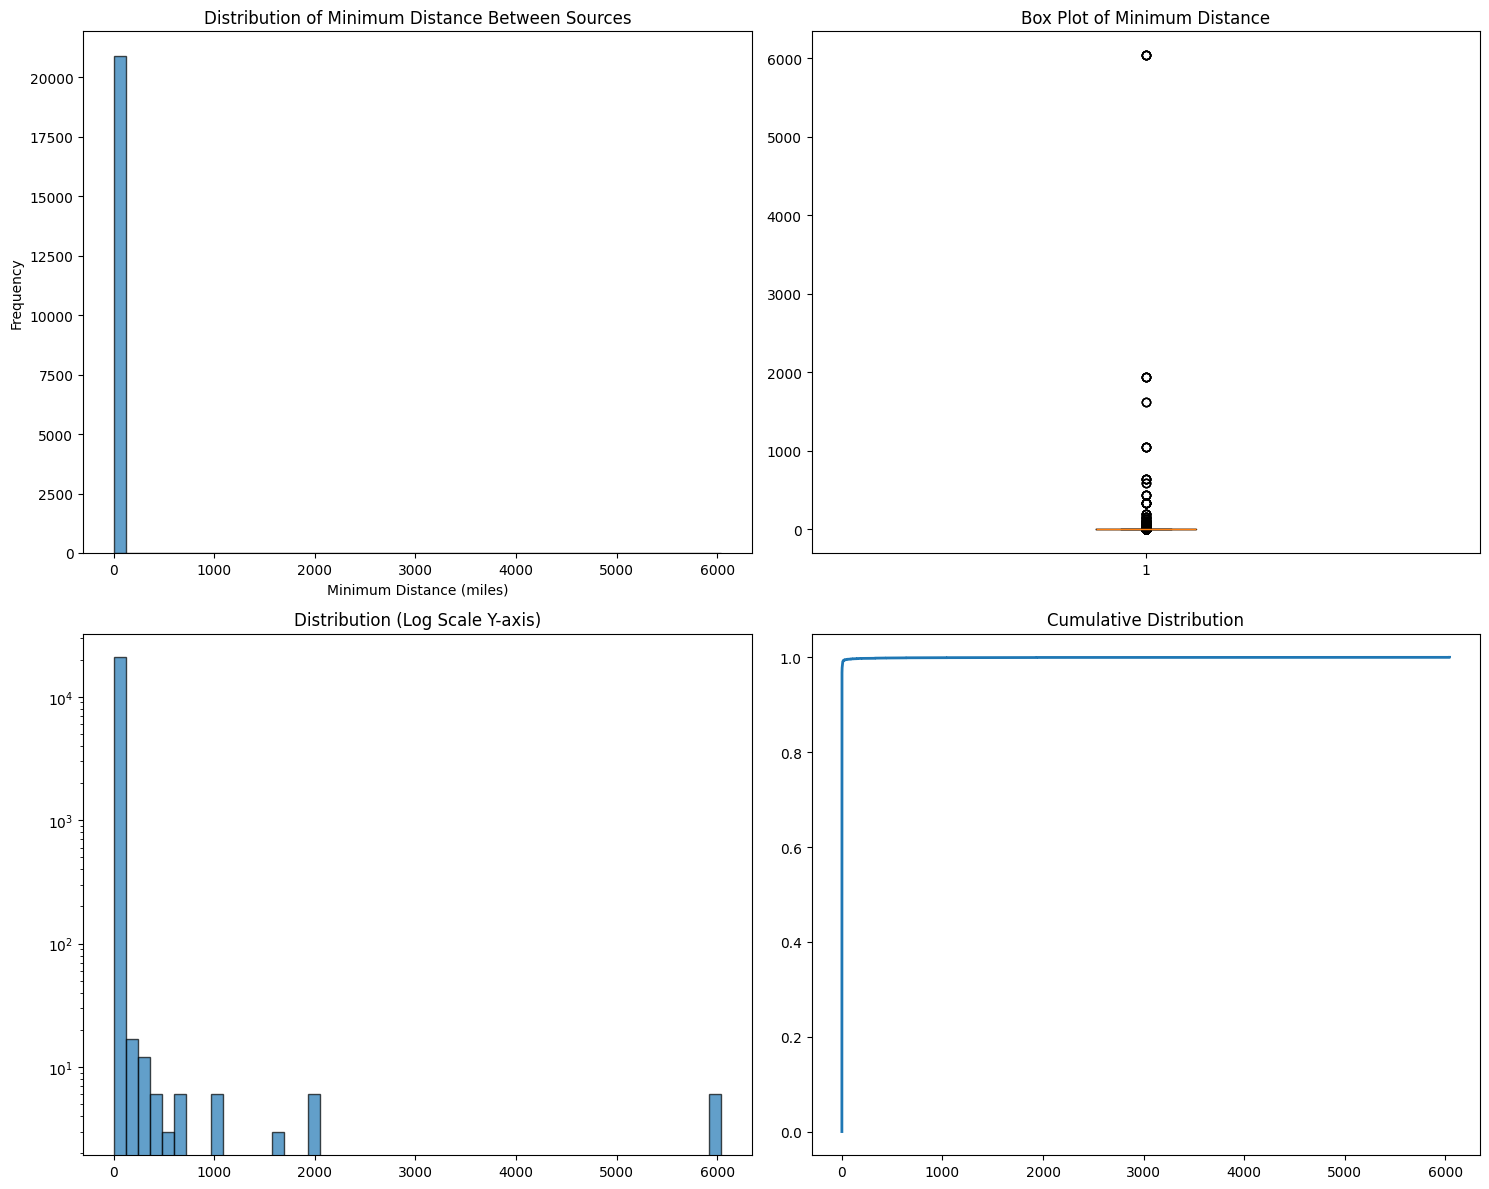

In [4]:
# Summary statistics
import matplotlib.pyplot as plt

filtered = df[df['min_distance_miles'] > 0]
print(f'Total records: {len(df):,}')
print(f'Records with distance comparisons: {len(filtered):,}')
print(f'Records with no distance comparisons: {len(df) - len(filtered):,}')
print(f'\nBasic statistics for min_distance_miles (excluding zeros):')
print(filtered['min_distance_miles'].describe())

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].hist(filtered['min_distance_miles'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Minimum Distance Between Sources')
axes[0, 0].set_xlabel('Minimum Distance (miles)')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].boxplot(filtered['min_distance_miles'])
axes[0, 1].set_title('Box Plot of Minimum Distance')

axes[1, 0].hist(filtered['min_distance_miles'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Distribution (Log Scale Y-axis)')

sorted_d = np.sort(filtered['min_distance_miles'])
axes[1, 1].plot(sorted_d, np.arange(1, len(sorted_d) + 1) / len(sorted_d), linewidth=2)
axes[1, 1].set_title('Cumulative Distribution')

plt.tight_layout()
plt.show()

In [5]:
# Save
df.to_csv(OUT_FILE, index=False)
print(f'Saved: {OUT_FILE}')
print(f'Final shape: {df.shape}')

Saved: C:\Users\Owner\Desktop\Geocoding_Truck_Stops\data\1_derived\5_geocode_truck_stops\2_cross_source_distances.csv
Final shape: (38135, 137)
